In [1]:
import numpy as np
import torch 
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev
from scipy import interpolate

In [2]:
#load in test.csv and test_pv_xrd.pt
#they are in /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only
test_df = pd.read_csv('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/df4.csv')
test_xrd = torch.load('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd_dict_3.pt')

In [3]:
#select only [:8500] of the values in test_xrd
for key in test_xrd.keys():
    test_xrd[key] = test_xrd[key][:,:8500]

In [4]:
#save the test_xrd dict
torch.save(test_xrd, '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd_dict_3.pt')

In [5]:
import matplotlib.pyplot as plt
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.core import Structure

def plot_xrd_pattern_from_string(index, plot = False):

    cif_string = test_df['cif'][index]
    xrd_from_test_xrd = test_xrd[test_df['material_id'][index]].numpy()

    # Load the structure from the CIF string
    structure = Structure.from_str(cif_string, fmt="cif")
    # Initialize the XRD calculator with Cu Kα radiation
    xrd_calculator = XRDCalculator(wavelength="CuKa")

    # Get the XRD pattern
    pattern = xrd_calculator.get_pattern(structure)

    myrange = np.arange(5, 90, 0.01)

    #sum the peaks in the bins defined by the range (this adds to the )
    summed_peaks = np.zeros(len(myrange))
    for i in range(len(pattern.x)):
        for j in range(len(myrange)-1):
            if pattern.x[i] > myrange[j] and pattern.x[i] < myrange[j+1]:
                summed_peaks[j] += pattern.y[i]
    summed_peaks = summed_peaks / np.max(summed_peaks)

    #for the peaks that are non-zero in summed-peaks, find the difference in intensity compared to the test_xrd
    residuals = np.zeros(len(summed_peaks))
    for i in range(len(summed_peaks)):
        if summed_peaks[i] > 0.2:
            #compare to the max within 10 bins of the peak
            window = 10
            if window > 0:
                residuals[i] = np.max(xrd_from_test_xrd[0][i-window:i+window]) / summed_peaks[i]
            else:
                residuals[i] = summed_peaks[i] - xrd_from_test_xrd[0][i]

    non_zero_residuals = residuals[residuals != 0]
    if plot == True:
        # Plot the pattern
        plt.figure(figsize=(10, 6))
        # plt.vlines(pattern.x, 0, pattern.y, colors='b')
        plt.vlines(myrange, 0, summed_peaks, colors='b')
        plt.plot(myrange, xrd_from_test_xrd[0], 'r', alpha = 0.5)
        plt.xlabel('2θ')
        plt.ylabel('Intensity')
        plt.title('X-ray Diffraction Pattern')
        plt.xlim(30,40)
        plt.show()

        #plot the residuals
        plt.figure(figsize=(10, 6))
        plt.plot(myrange, residuals)
        plt.xlabel('2θ')
        plt.ylabel('Intensity')
        plt.title('Residuals')
        plt.xlim(30,40)
        plt.show()
        
        # #get non-zero residuals
        # plt.figure(figsize=(5, 3))
        # plt.hist(non_zero_residuals, bins = 10)
        # plt.xlabel('Residuals')
        # plt.ylabel('Counts')
        # plt.title('Residuals')
        # plt.show()
    return residuals, non_zero_residuals


In [6]:
index = 3
residuals, non_zero_residuals = plot_xrd_pattern_from_string(index)

In [7]:
list_of_residuals = []
list_of_non_zero_residuals = []
for i in range(100):
    residuals, non_zero_residuals = plot_xrd_pattern_from_string(i, plot = False)
    list_of_residuals.append(residuals)
    list_of_non_zero_residuals.append(non_zero_residuals)

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


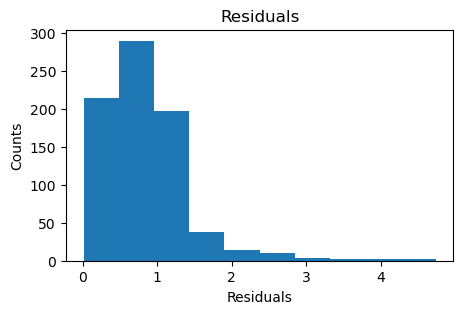

In [8]:
#make a histogram of the residuals
non_zero_residuals = np.concatenate(list_of_non_zero_residuals)
plt.figure(figsize=(5, 3))
plt.hist(non_zero_residuals, bins = 10)
plt.xlabel('Residuals')
plt.ylabel('Counts')
plt.title('Residuals')
plt.show()

2.1299178874418425 0 0.3836337942728039


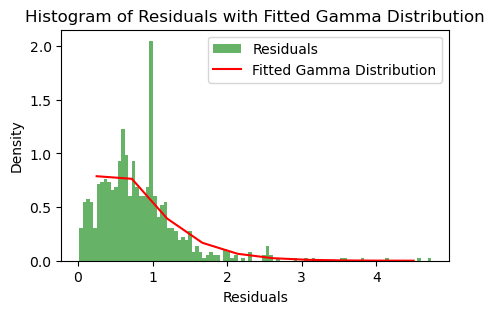

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming non_zero_residuals is already defined
# Generate histogram data
hist_data, bin_edges = np.histogram(non_zero_residuals, bins=10, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Fit a gamma distribution to the data
alpha, loc, scale = stats.gamma.fit(non_zero_residuals, floc=0)

#print the alpha, loc, and scale
print(alpha, loc, scale)

# Create a range of values to fit the gamma distribution
fitted_data = stats.gamma.pdf(bin_centers, alpha, loc, scale)

# Plot the histogram
plt.figure(figsize=(5, 3))
plt.hist(non_zero_residuals, bins=100, density=True, alpha=0.6, color='g', label='Residuals')

# Plot the fitted distribution
plt.plot(bin_centers, fitted_data, 'r-', label='Fitted Gamma Distribution')

# Add labels and title
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Histogram of Residuals with Fitted Gamma Distribution')
plt.legend()

# Show the plot
plt.show()


In [37]:
# Number of samples to generate
n_samples = 100000

# Generate samples from the fitted gamma distribution
gamma_samples = stats.gamma.rvs(alpha, loc, scale, size=n_samples)
print(min(gamma_samples), max(gamma_samples))

0.002500739638031109 5.55205333266792


(array([1.21271037e-01, 3.54442987e-01, 5.53738333e-01, 6.91046699e-01,
        7.71053149e-01, 8.41509279e-01, 8.93044965e-01, 9.02054700e-01,
        9.14848524e-01, 8.82593672e-01, 8.69619653e-01, 8.16282020e-01,
        7.94658655e-01, 7.39879464e-01, 6.87983389e-01, 6.44196075e-01,
        6.04012656e-01, 5.50855217e-01, 5.18780560e-01, 4.59316307e-01,
        4.37873136e-01, 3.91743292e-01, 3.58947855e-01, 3.35702738e-01,
        3.05790417e-01, 2.69030697e-01, 2.44344022e-01, 2.14972285e-01,
        1.99295345e-01, 1.72806723e-01, 1.54967447e-01, 1.47219075e-01,
        1.27037268e-01, 1.16225586e-01, 1.04693124e-01, 8.93765744e-02,
        8.48717067e-02, 7.49609979e-02, 6.00048372e-02, 6.00048372e-02,
        5.51395801e-02, 4.75714025e-02, 4.27061454e-02, 3.96428354e-02,
        3.09934895e-02, 2.88311530e-02, 2.25243383e-02, 2.43262854e-02,
        2.10827806e-02, 1.69383024e-02, 1.80194706e-02, 1.08116824e-02,
        1.29740189e-02, 8.82954061e-03, 7.20778825e-03, 8.108761

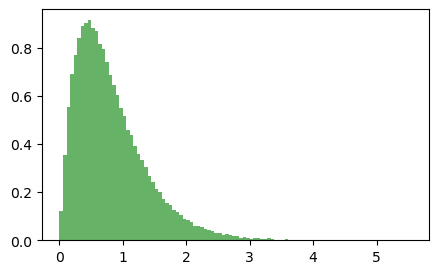

In [38]:
#plot the histogram of the gamma samples
plt.figure(figsize=(5, 3))
plt.hist(gamma_samples, bins=100, density=True, alpha=0.6, color='g', label='Gamma Samples')

In [39]:
import numpy as np
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import matplotlib.pyplot as plt

def modify_xrd(index, alpha, scale): 
    cif_string = test_df['cif'][index]
    xrd_from_test_xrd = test_xrd[test_df['material_id'][index]].numpy()

    # Load the structure from the CIF string
    structure = Structure.from_str(cif_string, fmt="cif")
    # Initialize the XRD calculator with Cu Kα radiation
    xrd_calculator = XRDCalculator(wavelength="CuKa")

    # Get the XRD pattern
    pattern = xrd_calculator.get_pattern(structure)

    myrange = np.arange(5, 90, 0.01)

    # Sum the peaks in the bins defined by the range
    summed_peaks = np.zeros(len(myrange))
    for i in range(len(pattern.x)):
        for j in range(len(myrange)-1):
            if pattern.x[i] > myrange[j] and pattern.x[i] < myrange[j+1]:
                summed_peaks[j] += pattern.y[i]
    summed_peaks = summed_peaks / np.max(summed_peaks)

    n_samples = len(summed_peaks)
    gamma_samples = stats.gamma.rvs(alpha, loc, scale, size=n_samples)

    # Multiply each peak by a random number from the gamma distribution
    modified_peaks = summed_peaks * gamma_samples

    #renormalize the modified peaks
    modified_peaks = modified_peaks / np.max(modified_peaks)

    # Plot the before and after
    plt.figure(figsize=(10, 6))
    plt.vlines(myrange, 0, summed_peaks, colors='b', label='Original Peaks')
    plt.vlines(myrange, 0, modified_peaks, colors='r', alpha=0.5, label='Modified Peaks')
    plt.xlabel('2θ')
    plt.ylabel('Intensity')
    plt.title('X-ray Diffraction Pattern')
    plt.legend()
    plt.show()


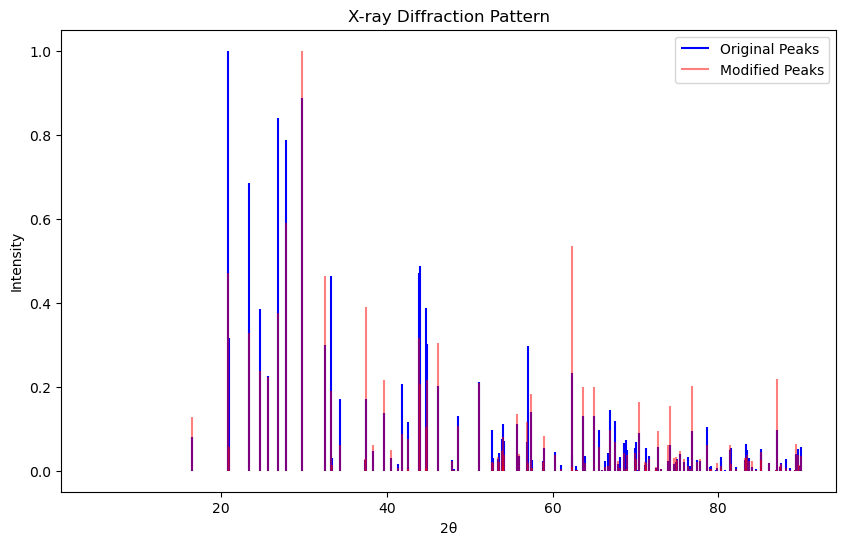

In [40]:
modify_xrd(6, alpha, scale)

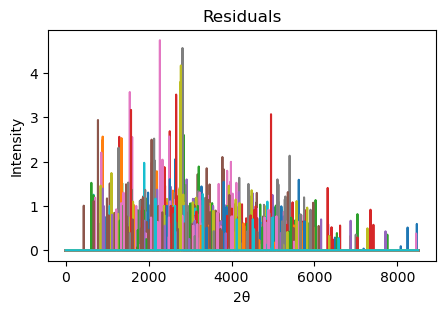

In [82]:
#plot the residuals
plt.figure(figsize=(5, 3))

for i in range(100):
    plt.plot(list_of_residuals[i])
    plt.xlabel('2θ')
    plt.ylabel('Intensity')
    plt.title('Residuals')
plt.show()
